In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
import warnings

In [4]:
#### This code provides weeklong smooth transitions into and out of modeled data segments. This is prefereable, but it will not work as writted in future versions of pandas, so if this ceases to work, revert to the previous cell.

# Load the combined data
combined_data = pd.read_csv("../../../data/streamflow/gauge_flow/compiled_gauge_flow_raw/compiled_gauge_flow_raw.csv", parse_dates=['Date'], index_col='Date')
modeled_data = pd.read_csv("../../../data/streamflow/vic_flow/q_sim_PMET.csv", parse_dates=['Date'], index_col='Date')

# Ensure the output directories exist
output_dir_summary = "../../../data/streamflow/franken_flow/work_summary"
output_dir_final = "../../../data/streamflow/franken_flow"
os.makedirs(output_dir_summary, exist_ok=True)
os.makedirs(output_dir_final, exist_ok=True)

# Define the mapping between river names and their corresponding codes
river_name_to_code = {
    "Aysen": "X11342001",
    "Cisnes": "X11147001",
    "Palena": "X11040001",
    "Puelo": "X10523002",
    "Yelcho": "X10704002"
}

# Function to remove repeated data
def remove_repeated_data(data):
    repeated_summary_list = []

    for river in data.columns:
        river_data = data[river]
        repeated = (river_data == river_data.shift()) & (river_data == river_data.shift(-1))
        repeated_groups = river_data[repeated].groupby((repeated != repeated.shift()).cumsum())

        for name, group in repeated_groups:
            if len(group) > 1:
                start_date = group.index[0]
                end_date = group.index[-1]
                duration = len(group)
                value = group.iloc[0]
                repeated_summary_list.append({
                    'River': river,
                    'Start Date': start_date,
                    'End Date': end_date,
                    'Duration': duration,
                    'Value': value,
                    'Removed': 'Yes'
                })
                data.loc[start_date:end_date, river] = np.nan

    repeated_summary = pd.DataFrame(repeated_summary_list)
    return data, repeated_summary

# Function to handle zero values and skipped dates
def handle_zeros_and_skipped_dates(data):
    new_data = pd.DataFrame(index=data.index)  # Initialize a new DataFrame with the same index
    for river in data.columns:
        river_data = data[river]

        # Replace 0 values with NaN
        river_data = river_data.replace(0, np.nan)

        # Ensure all dates within the range are present
        first_date = river_data.dropna().index[0]
        last_date = river_data.dropna().index[-1]
        full_date_range = pd.date_range(start=first_date, end=last_date)
        river_data = river_data.reindex(full_date_range)

        new_data[river] = river_data

    return new_data

########### HERE IS WHERE YOU CHANGE PARAMETERS FOR THE GAP-FILLING

# Function to fill gaps with moving average
def fill_gaps_with_moving_average(data, gap_start, gap_end):
    gap_duration = (gap_end - gap_start).days + 1
    window = max(2 * gap_duration, 1)  # Ensure window is at least 1
    filled_data = data.copy()
    filled_data[gap_start:gap_end] = filled_data.rolling(window=window, min_periods=1, center=True).mean()[gap_start:gap_end]
    return filled_data, f"rolling average with {window} day window"

# Function to fill gaps with modeled data
def fill_gaps_with_modeled_data(data, modeled_data, gap_start, gap_end, river_code):
    if all(date in modeled_data.index for date in pd.date_range(gap_start, gap_end)):
        data[gap_start:gap_end] = modeled_data.loc[gap_start:gap_end, river_code]
        return data, "modeled q_sim_PMET data"
    else:
        return data, "left unfilled"

# Function to handle gaps
def handle_gaps(data, modeled_data, river_name_to_code):
    gap_summary_list = []

    for river in data.columns:
        river_code = river_name_to_code[river]  # Map river name to river code
        river_data = data[river]
        first_date = river_data.dropna().index[0]
        last_date = river_data.dropna().index[-1]
        river_data = river_data[first_date:last_date]  # Restrict data to the range with actual data
        is_gap = river_data.isna()
        gap_groups = is_gap.groupby((is_gap != is_gap.shift()).cumsum())

        for name, group in gap_groups:
            if group.all():
                gap_start = group.index[0]
                gap_end = group.index[-1]
                gap_duration = (gap_end - gap_start).days + 1

                if gap_duration <= 21:
                    data[river], method = fill_gaps_with_moving_average(data[river], gap_start, gap_end)
                else:
                    data[river], method = fill_gaps_with_modeled_data(data[river], modeled_data, gap_start, gap_end, river_code)

                    # Remove 7 days on either side of the modeled data and refill with rolling average
                    buffer_days = 7
                    before_gap_start = gap_start - pd.Timedelta(days=buffer_days)
                    after_gap_end = gap_end + pd.Timedelta(days=buffer_days)
                    
                    # Fill 7-day buffers with rolling average
                    if before_gap_start in data.index and after_gap_end in data.index:
                        data[river].loc[before_gap_start:gap_start-pd.Timedelta(days=1)] = np.nan
                        data[river].loc[gap_end+pd.Timedelta(days=1):after_gap_end] = np.nan
                        data[river], _ = fill_gaps_with_moving_average(data[river], before_gap_start, gap_start-pd.Timedelta(days=1))
                        data[river], _ = fill_gaps_with_moving_average(data[river], gap_end+pd.Timedelta(days=1), after_gap_end)
                        
                        gap_summary_list.append({
                            'River': river,
                            'Start Date': before_gap_start,
                            'End Date': gap_start - pd.Timedelta(days=1),
                            'Duration': buffer_days,
                            'Method': "blended rolling average"
                        })
                        gap_summary_list.append({
                            'River': river,
                            'Start Date': gap_end + pd.Timedelta(days=1),
                            'End Date': after_gap_end,
                            'Duration': buffer_days,
                            'Method': "blended rolling average"
                        })

                gap_summary_list.append({
                    'River': river,
                    'Start Date': gap_start,
                    'End Date': gap_end,
                    'Duration': gap_duration,
                    'Method': method
                })

    gap_summary = pd.DataFrame(gap_summary_list)
    return data, gap_summary

# Step 1: Handle zeros and skipped dates
combined_data = handle_zeros_and_skipped_dates(combined_data)

# Step 2: Remove repeated data
combined_data, repeated_summary = remove_repeated_data(combined_data)
repeated_summary.to_csv(os.path.join(output_dir_summary, "repeated_values_summary.csv"), index=False)
print("Repeated data removed and summary saved.")

# Step 3: Handle gaps
combined_data, gap_summary = handle_gaps(combined_data, modeled_data, river_name_to_code)
gap_summary.to_csv(os.path.join(output_dir_summary, "gap_filling_summary.csv"), index=False)
print("Data gaps handled and summary saved.")

# Trim data to the last common date with data for all rivers
last_common_date = combined_data.dropna().index[-1]
combined_data = combined_data.loc[:last_common_date]

# Step 4: Save the final dataset
combined_data.to_csv(os.path.join(output_dir_final, "franken_flow.csv"))
print("Final dataset saved to ../franken_flow/franken_flow.csv")

# Function to check for quality control issues
def quality_control_checks(data):
    quality_issues = {
        'River': [],
        'Issue': [],
        'Date': []
    }

    for river in data.columns:
        river_data = data[river]
        # Determine the valid data range for the river
        first_date = river_data.dropna().index[0]
        last_date = river_data.dropna().index[-1]
        valid_data_range = river_data[first_date:last_date]
        
        # Check for 0 values
        zero_values = valid_data_range[valid_data_range == 0]
        for date in zero_values.index:
            quality_issues['River'].append(river)
            quality_issues['Issue'].append('Zero Value')
            quality_issues['Date'].append(date)

        # Check for blank entries (NaN)
        blank_entries = valid_data_range[valid_data_range.isna()]
        for date in blank_entries.index:
            quality_issues['River'].append(river)
            quality_issues['Issue'].append('Blank Entry')
            quality_issues['Date'].append(date)

        # Check for skipped dates within the valid range
        full_date_range = pd.date_range(start=first_date, end=last_date)
        missing_dates = full_date_range.difference(valid_data_range.dropna().index)
        for date in missing_dates:
            quality_issues['River'].append(river)
            quality_issues['Issue'].append('Skipped Date')
            quality_issues['Date'].append(date)

    quality_issues_df = pd.DataFrame(quality_issues)
    return quality_issues_df

# Perform quality control checks
quality_issues_df = quality_control_checks(combined_data)

# Print quality control issues
if not quality_issues_df.empty:
    print("Quality Control Issues Found:")
    print(quality_issues_df)
else:
    print("No Quality Control Issues Found.")

# Save the quality control issues to a CSV file
quality_issues_df.to_csv("../../../data/streamflow/franken_flow/work_summary/quality_control_issues.csv", index=False)
print("Quality control issues saved to ../franken_flow/work_summary/quality_control_issues.csv")

warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore")

Repeated data removed and summary saved.


/var/folders/x8/mpvljg_94_nb_bqxjncltssw0000gn/T/ipykernel_1288/938684552.py:116: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data[river].loc[before_gap_start:gap_start-pd.Timedelta(days=1)] = np.nan
/var/folders/x8/mpvljg_94_nb_bqxjncltss

Data gaps handled and summary saved.
Final dataset saved to ../franken_flow/franken_flow.csv
No Quality Control Issues Found.
Quality control issues saved to ../franken_flow/work_summary/quality_control_issues.csv



Analysis for Aysen:



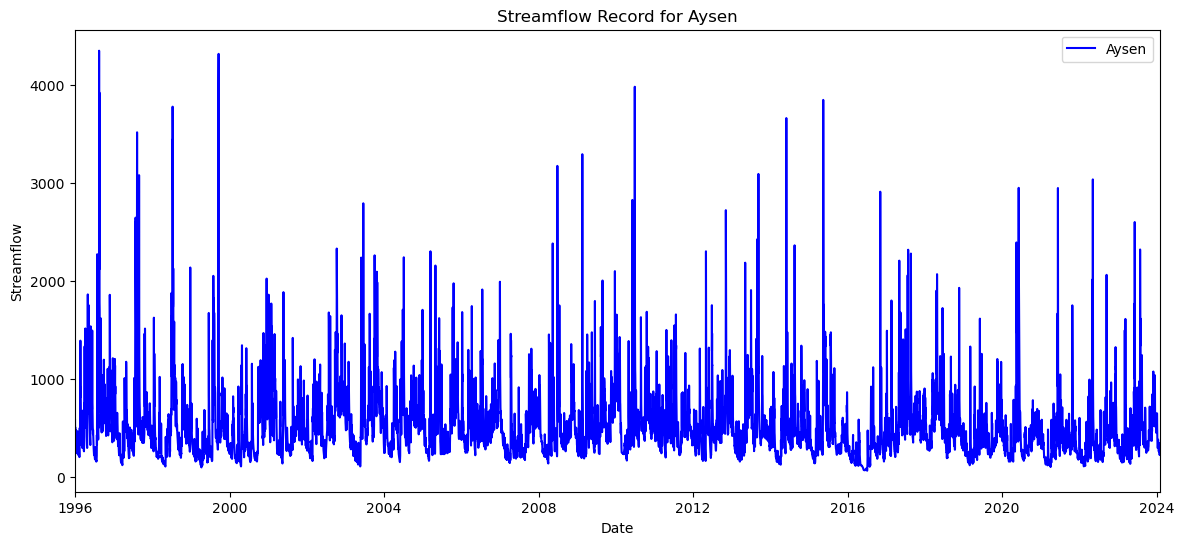

Streamflow Summary:
  First Date  Last Date  Number of Gaps  Mean Streamflow  \
0 1995-12-30 2024-01-31               1       512.579314   

   Standard Deviation Streamflow  Minimum Streamflow  
0                     348.308834                67.3  

Repeated Values Summary:
  Start_Date   End_Date  Duration  Value
0 1996-01-16 1996-01-17         2  264.0
1 2007-07-10 2007-07-11         2  218.0

No gaps found.

Analysis for Cisnes:



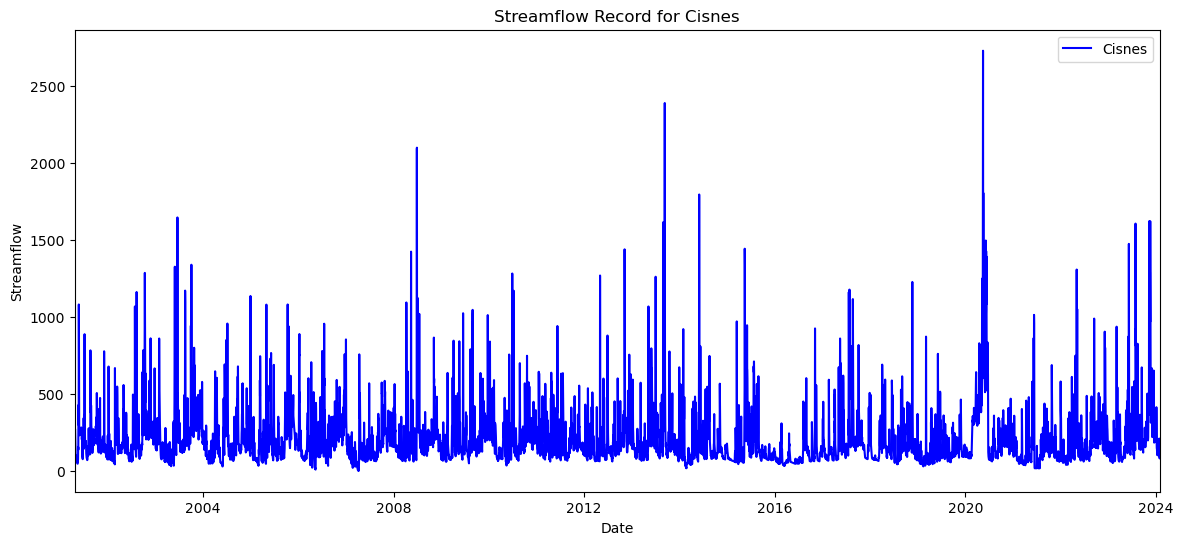

Streamflow Summary:
  First Date  Last Date  Number of Gaps  Mean Streamflow  \
0 2001-04-23 2024-01-31               1       204.432693   

   Standard Deviation Streamflow  Minimum Streamflow  
0                     182.686236                1.52  

Repeated Values Summary:
  Start_Date   End_Date  Duration   Value
0 2021-07-14 2021-07-15         2  17.417

No gaps found.

Analysis for Palena:



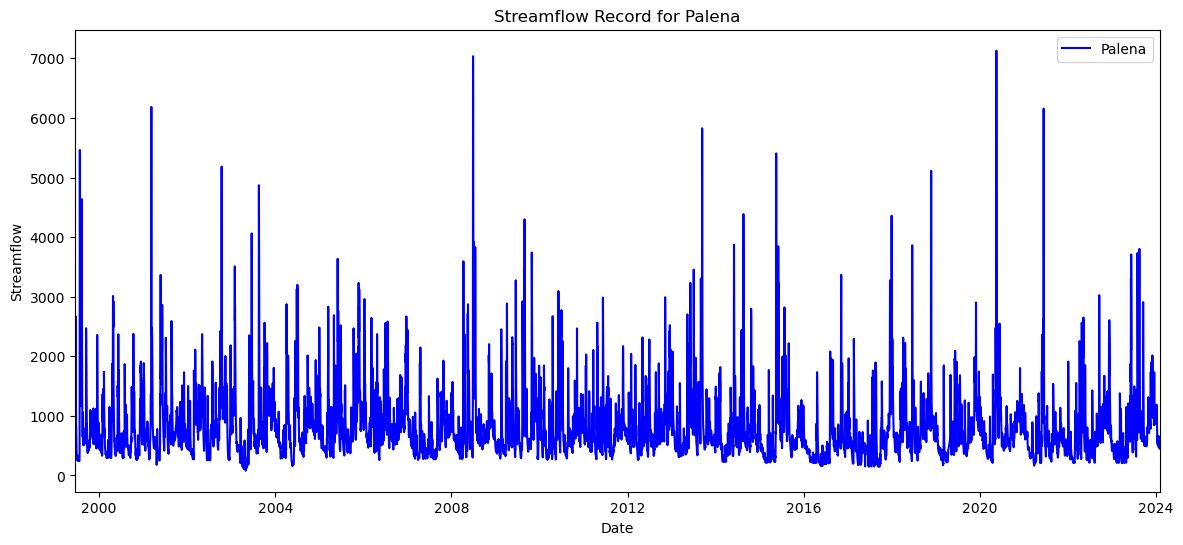

Streamflow Summary:
  First Date  Last Date  Number of Gaps  Mean Streamflow  \
0 1999-06-13 2024-01-31               1       797.794132   

   Standard Deviation Streamflow  Minimum Streamflow  
0                     559.548715                79.6  

Repeated Values Summary:
  Start_Date   End_Date  Duration  Value
0 2000-03-07 2000-03-08         2  295.0
1 2005-04-27 2005-04-28         2  296.0
2 2007-08-20 2007-08-21         2  292.0
3 2008-03-13 2008-03-14         2  296.0
4 2013-04-28 2013-04-29         2  370.0
5 2017-07-12 2017-07-15         4  151.0
6 2017-09-19 2017-09-21         3  151.0
7 2022-08-09 2022-08-10         2  213.9

No gaps found.

Analysis for Puelo:



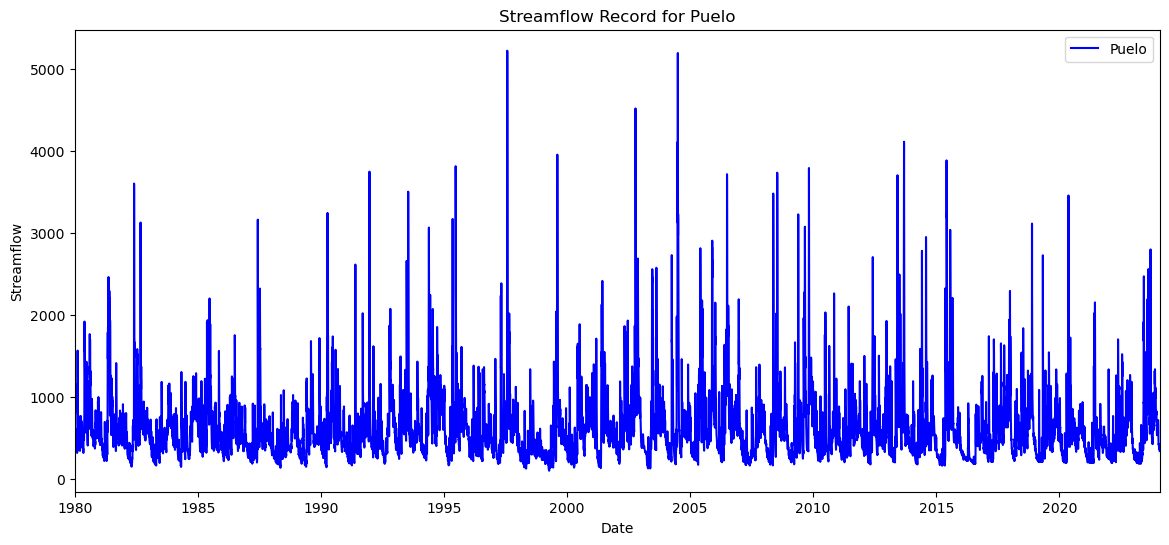

Streamflow Summary:
  First Date  Last Date  Number of Gaps  Mean Streamflow  \
0 1980-01-01 2024-01-31               0       606.629613   

   Standard Deviation Streamflow  Minimum Streamflow  
0                     413.136235               102.0  

Repeated Values Summary:
  Start_Date   End_Date  Duration    Value
0 1987-02-12 1987-02-13         2  262.000
1 1988-10-03 1988-10-04         2  360.000
2 1992-01-21 1992-01-22         2  393.000
3 2000-05-06 2000-05-07         2  339.000
4 2009-10-19 2009-10-20         2  348.000
5 2012-08-19 2012-08-20         2  587.000
6 2017-02-13 2017-02-14         2  210.000
7 2019-03-18 2019-03-19         2  232.000
8 2023-04-24 2023-04-25         2  187.593

No gaps found.

Analysis for Yelcho:



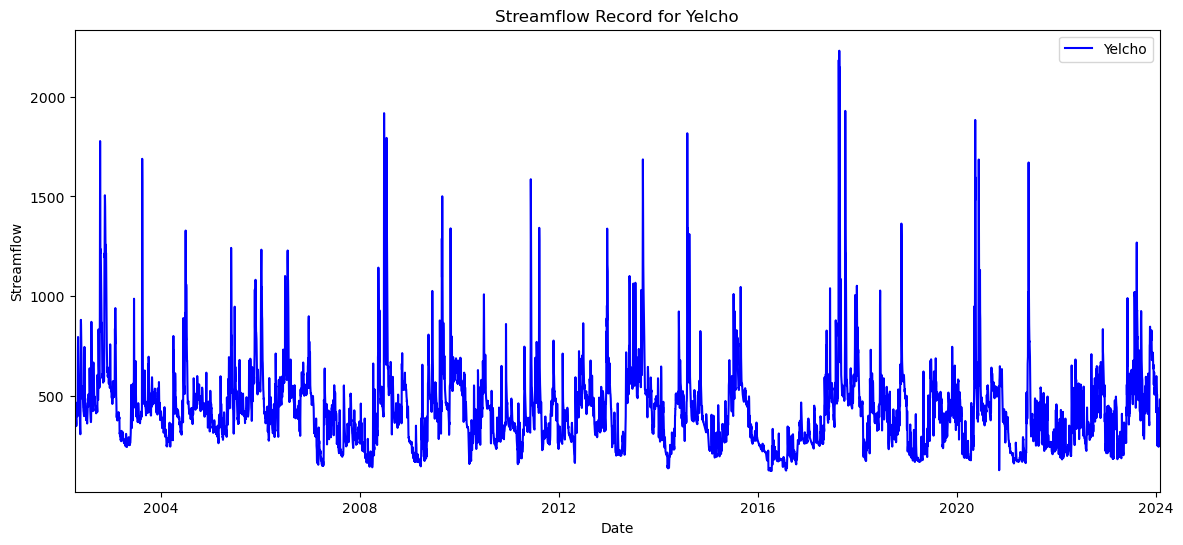

Streamflow Summary:
  First Date  Last Date  Number of Gaps  Mean Streamflow  \
0 2002-04-10 2024-01-31               1       428.038753   

   Standard Deviation Streamflow  Minimum Streamflow  
0                     202.015959               124.0  

Repeated Values Summary:
  Start_Date   End_Date  Duration  Value
0 2008-12-06 2008-12-07         2  534.0
1 2009-11-13 2009-11-14         2  525.0
2 2010-08-10 2010-08-11         2  439.0
3 2013-02-23 2013-02-24         2  216.0
4 2016-04-05 2016-04-06         2  124.0

No gaps found.


In [6]:
#### This code block performs the same analysis as was performed in the gauge_flow_merger script, outputting summary stats to a quality_control_stats folder. The puerpose of this block is to highlight the success of the franken_flow data cleanup.

# Ensure the output directory exists

output_dir = "../../../data/streamflow/franken_flow/quality_control_stats"
os.makedirs(output_dir, exist_ok=True)

# Load the combined data
combined_data = pd.read_csv("../../../data/streamflow/franken_flow/franken_flow.csv", parse_dates=['Date'])

# Function to plot streamflow and highlight gaps
def plot_streamflow_with_gaps(data, river_name):
    river_data = data[['Date', river_name]].dropna()
    plt.figure(figsize=(14, 6))
    plt.plot(river_data['Date'], river_data[river_name], label=river_name, color='blue')
    # Highlight gaps with vertical red bands
    gaps = data['Date'][data[river_name].isna() & (data['Date'] >= river_data['Date'].min()) & (data['Date'] <= river_data['Date'].max())]
    for gap in gaps:
        plt.axvline(x=gap, color='red', linestyle='--', alpha=0.5)
    plt.xlim(river_data['Date'].min(), river_data['Date'].max())
    plt.xlabel('Date')
    plt.ylabel('Streamflow')
    plt.title(f'Streamflow Record for {river_name}')
    plt.legend()
    plt.savefig(f"{output_dir}/{river_name}_streamflow_plot.png")
    plt.show()  # Display the plot in the notebook

# Function to summarize streamflow data
def summarize_streamflow(data, river_name):
    summary = {}
    summary['First Date'] = data['Date'][data[river_name].notna()].min()
    summary['Last Date'] = data['Date'][data[river_name].notna()].max()
    summary['Number of Gaps'] = ((data[river_name].isna().astype(int).groupby(data[river_name].notna().astype(int).cumsum()).sum() > 0).sum())
    summary['Mean Streamflow'] = data[river_name].mean()
    summary['Standard Deviation Streamflow'] = data[river_name].std()
    summary['Minimum Streamflow'] = data[river_name].min()
    return summary

# Function to identify sequential repeated values
def identify_repeated_values(data, river_name):
    data['Repeated'] = (data[river_name] == data[river_name].shift())
    repeated_groups = data.groupby((data['Repeated'] != data['Repeated'].shift()).cumsum())
    
    repeated_summary_list = []

    for name, group in repeated_groups:
        if group['Repeated'].all() and len(group) > 1:  # Ensure we have a repeated group of more than one
            repeated_summary_list.append({
                'Start_Date': group['Date'].iloc[0],
                'End_Date': group['Date'].iloc[-1],
                'Duration': len(group),
                'Value': group[river_name].iloc[0]
            })

    repeated_summary = pd.DataFrame(repeated_summary_list)
    
    return repeated_summary

# Function to summarize gaps in the data
def summarize_gaps(data, river_name):
    first_date = data['Date'][data[river_name].notna()].min()
    last_date = data['Date'][data[river_name].notna()].max()
    data_within_range = data[(data['Date'] >= first_date) & (data['Date'] <= last_date)].copy()
    data_within_range.loc[:, 'Gap'] = data_within_range[river_name].isna()
    data_within_range.loc[:, 'GapGroup'] = (data_within_range['Gap'] != data_within_range['Gap'].shift()).cumsum()
    gap_summary = data_within_range[data_within_range['Gap']].groupby('GapGroup').agg({'Date': ['first', 'last'], 'Gap': 'size'})
    gap_summary.columns = ['Start Date', 'End Date', 'Duration']
    gap_summary = gap_summary.reset_index(drop=True)
    gap_summary['Duration'] = gap_summary['Duration'] - 1  # Subtract 1 to get the duration in days
    return gap_summary

# Analyze each river
rivers = combined_data.columns[1:]  # Exclude the 'Date' column

for river in rivers:
    print(f"\nAnalysis for {river}:\n")
    
    # Plot streamflow with gaps
    plot_streamflow_with_gaps(combined_data, river)
    
    # Summarize streamflow data
    summary = summarize_streamflow(combined_data, river)
    summary_df = pd.DataFrame([summary])
    print("Streamflow Summary:")
    print(summary_df)
    summary_df.to_csv(f"{output_dir}/{river}_streamflow_summary.csv", index=False)
    
    # Identify repeated values
    repeated_values_summary = identify_repeated_values(combined_data, river)
    if not repeated_values_summary.empty:
        print("\nRepeated Values Summary:")
        print(repeated_values_summary)
        repeated_values_summary.to_csv(f"{output_dir}/{river}_repeated_values_summary.csv", index=False)
    else:
        print("\nNo repeated values found.")
    
    # Summarize gaps in the data
    gap_summary = summarize_gaps(combined_data, river)
    if not gap_summary.empty:
        print("\nGap Summary:")
        print(gap_summary)
        gap_summary.to_csv(f"{output_dir}/{river}_gap_summary.csv", index=False)
    else:
        print("\nNo gaps found.")